In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "/Volumes/MLAI DATA/datasets/digit-recognizer"

train = pd.read_csv(f"{DATA_PATH}/train.csv")
test = pd.read_csv(f"{DATA_PATH}/test.csv")

print(train.shape)
train.head()

(42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [3]:
train.iloc[0, 1:].values.reshape(28,28)

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 188, 255,  94,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0, 191, 250, 253,  93,   0,   0,   0,
          0,   0],
       [  

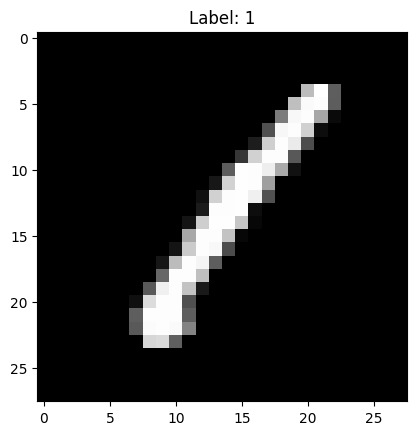

In [4]:
image = train.iloc[0, 1:].values.reshape(28,28)

plt.imshow(image, cmap="gray")
plt.title(f"Label: {train.iloc[0,0]}")
plt.show()

In [5]:
X = train.iloc[:,1:].values
y = train.iloc[:,0].values

print(X.shape)
print(y.shape)

(42000, 784)
(42000,)


In [6]:
X = X / 255.0
test_X = test.values / 255.0

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_valid.shape)

(33600, 784) (8400, 784)


In [9]:
print("X_train" in globals())
print("X_valid" in globals())

True
True


In [10]:
X_train = X_train.reshape(-1,28,28)
X_valid = X_valid.reshape(-1,28,28)
test_X = test_X.reshape(-1,28,28)

print(X_train.shape, X_valid.shape, test_X.shape)

(33600, 28, 28) (8400, 28, 28) (28000, 28, 28)


In [11]:
X_train = X_train.reshape(-1,1,28,28)
X_valid = X_valid.reshape(-1,1,28,28)
test_X = test_X.reshape(-1,1,28,28)

print(X_train.shape, X_valid.shape, test_X.shape)

(33600, 1, 28, 28) (8400, 1, 28, 28) (28000, 1, 28, 28)


In [12]:
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_valid = torch.tensor(X_valid, dtype=torch.float32)
test_X = torch.tensor(test_X, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_valid = torch.tensor(y_valid, dtype=torch.long)

print(X_train.shape, y_train.shape)

torch.Size([33600, 1, 28, 28]) torch.Size([33600])


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size= 64, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size= 64, shuffle=False)

In [14]:
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1,32, kernel_size=3, padding=1) # Conv = Convolution / 2d = 2차원 이미지를 다룸 2차원 이미지에서 특징을 뽑는 층

        self.relu = nn.ReLU() # ReLU =  Rectified Linear Unit의 줄임말 음수는 0 양수는 그대로 변형시키는 언어 / 불필요한 음수 신호를 제거하고 비선형성을 주기 위해 사용
                              # 복잡한 곡선, 복잡한 패턴, 비선형 관계를 학습하고 여러층을 쌓는 딥러닝 과정에서 선형계산만 하면 하나의 단순한 선형모델이 될 수 있으니 사용함.

        self.pool = nn.MaxPool2d(2,2) # Maximum pooling의 줄임말 / 이미지 크기를 줄이는 층 >> 예를 들어 2x2 구역을 보고 그안에서 가장 큰 값 하나만 남기는 것.
                                      # (2,2)는 커널사이즈2,스트라이드2를 뜻함 2x2칸씩 보고 2칸씩 이동하는것 / 중요한 특징, 계산량 감소, 위치변화에 덜 예민한 모델을 만들기위함

        self.conv2 = nn.Conv2d(32,64,kernel_size=3,padding=1) # kernel_size = ?x?크기의 작은 창으로 이미지를 분석 조금씩 보며 선,점,모서리 같은 패턴을 찾음
                                                              # padding =  이미지 가장자리에 0을 덧붙여 Convolution 할 때 이미지 가장자리 손실을 없애기 위해 사용

        self.fc1 = nn.Linear(64 * 7 * 7, 128) # Linear는 완전연결층(Fully Connected Layer) 앞에서 뽑아낸 특징들을 종합해 판단하는 단계
        self.fc2 = nn.Linear(128,10)          # 즉 Conv는 특징찾기, Linear는 최종 분류하기
                                              # (64*7*7은) conv와 pooling을 거친 데이터 모양이 (배치크기,64,7,7)이렇게 나오기 때문에 Linear에 넣기위해 한줄로 펴려면
                                              # 64 * 7 * 7 = 3136 즉 입력 노드 수는 3136개 / 뒷숫자인 128은 출력할 노드 개수 / 3136개의 특징을 128개로 압축시키는 작업 
                                              # 마지막 128,10은 숫자가 0,1,2,3,4,5,6,7,8,9 총 10개의 클래스니 마지막 10개의 점수를 내고 가장 큰점수를 가진 번호를 예측해 고름

    def forward(self,x): # forward == 모델의 설계도
        x = self.pool(self.relu(self.conv1(x))) # (1,28,28) => (32,14,14)로 변경
        x = self.pool(self.relu(self.conv2(x))) # (32,14,14) => (64,7,7)로 변경

        x = x.view(x.size(0), -1) # 펼치기 x.size(0)은 배치 크기64, -1은 나머지는 자동계산으로 설정 / 결과ex) (64,3136)
        x = self.relu(self.fc1(x)) # 특징 압축
        x = self.fc2(x) # 최종 출력
        return x


In [ ]:
model = SimpleCNN() # 모델 생성

criterion = nn.CrossEntropyLoss() # Cross = 교차 / Entropy = 정보량(불확실성) / Loss = 손실(틀린 정도) / 예측과 정답이 얼마나 다른지 계산하는 함수
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001) # optimizer = 최적화 도구 / 틀린만큼 모델을 어떻게 고칠지 결정
                                                            # Adam = Adaptive Moment Estimation 똑똑하게 가중치를 수정해주는 알고리즘
                                                            # model.parameters() = 모델 안의 모든 가중치(weight) Ex) Conv, Linear
                                                            # lr = Learning rate / 얼마나 크게 수정시킬지 / 너무 크면 왔다갔다 폭발, 너무작으면 너무느려서 거의안배움

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # GPU or CPU Mac은 NVIDIA CUDA를 지원안해서 CPU
model = model.to(device) # 모델을 CPU에 적용시키는 작업 / 데이터와 모델은 같은 장치에 있어야함

epochs = 5 # 반복 횟수 / 훈련 데이터 전체를 한바퀴 다보는게 1 epoch

for epoch in range(epochs): # epoch 횟수만큼 학습 반복
    model.train() # 모델을 학습모드로 전환 training
    train_loss = 0 # epoch동안 손실을 누적해서 기록하기 위한 변수

    for images, labels in train_loader: # train 데이터를 batch단위로 하나씩 꺼내오기
        images, labels = images.to(device), labels.to(device) # 데이터들도 model과 같은 디바이스로 옮겨주기

        optimizer.zero_grad() # 이전 batch에서 계산된 기울기를 초기화 / Pytorch는 기울기를 계속 누적하는데 초기화를 안하면 이전것과 이번것이 섞여버림 / 이번 batch 기준으로 업데이트
        outputs = model(images) # 모델이 이미지를 보고 예측값 생성 / ex) (64,10).. 64장의 이미지 각 이미지마다 10개의 숫자에 대한 점수가 10개
        loss = criterion(outputs, labels) # 모델 예측이 정답과 얼마나 다른지 계산 / 예를들어 정답이 2인데 모델이 2에 높은점수를 주면 loss가 낮고, 다른수에 높은점수를 주면 loss가 높다.
        loss.backward() # 위에서 계산한 오차를 바탕으로 어떤 가중치를 얼마나 고쳐야 하는지 계산하는 작업 / 틀린 원인을 뒤로 거슬러 올라가며 각 가중치의 책임을 계산 (정답 비교-> 오차 계산-> 뒤로 전달)
        optimizer.step() # 방금 계산한 기울기(gradient)를 이용해 실제로 가중치를 수정 / loss.backward() = 오답 분석, optimizer.step() = 실제 수정

        train_loss += loss.item() # 현재 batch의 loss를 숫자로 꺼내서 변수에 누적 / loss.item()은 tensor형태(파이썬숫자)라서 출력용 숫자로 변형하기위해 .item()을 사용

    model.eval() # 모델을 평가모드로 전환
    correct = 0 # 검증 데이터에서 맞춘 개수 카운트하려는 변수
    total = 0 # 검증 데이터의 전체 개수 카운트하는 변수

    with torch.no_grad(): # 검증할 때에는 gradient 계산하지 말라는 명령어 / 검증할때에는 학습 안하고 평가만 하니 역전파용 계산이 무쓸모.
        for images, labels in valid_loader: # 검증 데이터도 batch 단위로 꺼내오기 단, 이곳에선 train처럼 학습하지 않고 평가만 함.
            images, labels = images.to(device), labels.to(device)
            outputs = model(images) # 검증 데이터에 대해 모델의 예측
            _, predicted = torch.max(outputs, 1) # torch.max(outputs, 1)은 가장 큰값, 그 위치(index)를 반환하는데 우리는 index만 필요하니 앞의 값은 버려줌.
                                                 # 1의 의미는 Pytorch에서 0은 세로방향(행) 1이 가로방향(열)을 의미
                                                 # 코드 의미: 각 행(= 각 이미지)에 대해 가장 큰 값과 그 위치를 찾아라 / 각 행에서 가로방향으로 최대값 찾기 > 열방향으로 움직이며 계산
                                                 # dim = 그 축을 없애면서 연산, dim=1 > 열 방향으로 계산 > 행마다 결과
                                                 # dim=0 > 행 방향으로 계산 > 열마다 결과 / dim은 어느방향으로 훑을지!

            total += labels.size(0) # 이번 batch의 데이터 개수를 total에 더해주기. batch size가 64면 한번에 64추가
            correct += (predicted == labels).sum().item() # 이번 batch에서 맞춘 개수 세기 >> 예측과 정답을 비교해서 .sum()으로 True를 1처럼 세서 계산 후 .item()으로 숫자로 바꿔줌

        accuracy = correct / total # 전체 중에서 맞춘 비율
        print(f"Epoch {epoch+1}/{epochs}, Train loss: {train_loss:.4f}, Valid Accuracy: {accuracy:.4f}") # 현재 epoch의 학습상태 출력

Epoch 1/5, Train loss: 142.2962, Valid Accuracy: 0.9725
Epoch 2/5, Train loss: 34.9973, Valid Accuracy: 0.9825
Epoch 3/5, Train loss: 23.9341, Valid Accuracy: 0.9839
Epoch 4/5, Train loss: 17.8422, Valid Accuracy: 0.9851
Epoch 5/5, Train loss: 15.4764, Valid Accuracy: 0.9845


In [18]:
test_dataset = TensorDataset(test_X)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [20]:
model.eval()
predictions = []

with torch.no_grad():
    for images in test_loader:
        images = images[0].to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        predictions.extend(predicted.cpu().numpy()) # 예측 결과를 리스트에 하나하나 저장

In [21]:
submission = pd.DataFrame({
    "ImageId": range(1, len(predictions) + 1),
    "Label": predictions
})

submission.head()

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


In [22]:
submission.to_csv("sub_digitfirst.csv", index = False)

In [ ]:
print(len(predictions))

In [ ]:
# 모듈 불러오기 및 csv 읽기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "/Volumes/MLAI DATA/datasets/digit-recognizer"

train = pd.read_csv(f"{DATA_PATH}/train.csv")
test = pd.read_csv(f"{DATA_PATH}/test.csv")

print(train.shape)

train.head()

# X,y 분리
X = train.iloc[:,1:].values # X= 입력 데이터 (이미지 픽셀) / : = 모든행 , 1: 1번컬럼부터 끝까지
y = train.iloc[:,0].values #y= 정답 (숫자 라벨) / values = DataFrame -> numpy배열로 변환

print(X.shape)
print(y.shape)

# 정규화
X = X / 255.0 # 픽셀값 0~255 => 0~1로 축소 / 학습 안정화, 속도 향상, 딥러닝 기본 전처리를 위해
test_X = test.values / 255.0

# train/valid 분리
from sklearn.model_selection import train_test_split # 데이터를 나누는 도구

X_train, X_valid, y_train, y_valid = train_test_split( # 전체 데이터를 학습용+검증용으로 나눔 
    X, y, test_size=0.2, random_state=42 # 20% 검증용 데이터
)

print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

# reshape
X_train = X_train.reshape(-1, 28, 28) # 1차원 배열 -> 28x28 이미지로 변환 / (42000, 784)에서 (42000, 28, 28)로 변경 / -1은 자동으로 개수를 맞춰라
X_valid = X_valid.reshape(-1, 28, 28) 
test_X = test_X.reshape(-1, 28, 28)

print(X_train.shape, X_valid.shape, test_X.shape)

# 채널 차원 추가
X_train = X_train.reshape(-1,1,28,28) # CNN입력 형식 맞추기 (batch, channel, height, width)
X_valid = X_valid.reshape(-1,1,28,28)
test_X = test_X.reshape(-1,1,28,28)

print(X_train.shape, X_valid.shape, test_X.shape)

# Pytorch Tensor로 변환
import torch

X_train = torch.tensor(X_train, dtype=torch.float32) # numpy -> Torch Tensor로 변환 / Pytorch 모델은 tensor만 처리하기 때문
X_valid = torch.tensor(X_valid, dtype=torch.float32) # float32 = 입력 데이터(이미지)
test_X = torch.tensor(test_X, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long) # 정답 라벨 => Long / CrossEntropyLoss는 정답형을 정수로 받기때문
y_valid = torch.tensor(y_valid, dtype=torch.long)

print(X_train.shape, y_train.shape)

# 데이터 셋/데이터 로더 만들기
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train) # 입력(X)와 정답(y)를 하나로 묶어주는 것
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size= 64, shuffle=True) # 데이터를 한번에 64개씩 잘라서 모델에 넣어주는 역할 / 전체데이터를 한번에 넣으면 너무 느리고 메모리가 터지기 때문
valid_loader = DataLoader(valid_dataset, batch_size= 64, shuffle=False) # 배치사이즈 = 데이터를 몇개씩 묶어서 넣을건지 / 셔플은 데이터를 섞어 넣을건지 유무

# CNN모델 만들기
import torch.nn as nn

class ImprovedCNN(nn.Module): # nn.Module은 모델의 뼈대 / 가중치 저장, GPU 이동, 학습/평가 모드 전환, forward실행 등 CNN의 모든걸 가능하게 해주는 부모 클래스
    def __init__(self): # 객체가 만들어질때 자동 실행되는 함수, 모델을 만들 때 필요한 부품을 세팅하는 곳 / self = 이 객체(자기자신), 지금 만들고 있는 모델 자체 self를 붙여야 이 모델의 구성요소가 됨
                        # self를 안쓰면 self.conv1 = nn.Conv2d(...)와 같은 경우 모델이 conv1을 기억하지 못한다.
        super().__init__() # nn.Module 기능을 켜기 / 이 작업을 안 할 경우 Pytorch가 이걸 모델로 인식하지 못한다.

        self.conv1 = nn.Conv2d(1,32, kernel_size=3, padding=1) # Conv = Convolution / 2d = 2차원 이미지를 다룸 2차원 이미지에서 특징을 뽑는 층
        self.bn1 = nn.BatchNorm2d(32) # 32채널 데이터 정규화 / Conv -> BatchNorm -> ReLU

        self.relu = nn.ReLU() # ReLU =  Rectified Linear Unit의 줄임말 음수는 0 양수는 그대로 변형시키는 언어 / 불필요한 음수 신호를 제거하고 비선형성을 주기 위해 사용
                              # 복잡한 곡선, 복잡한 패턴, 비선형 관계를 학습하고 여러층을 쌓는 딥러닝 과정에서 선형계산만 하면 하나의 단순한 선형모델이 될 수 있으니 사용함.

        self.pool = nn.MaxPool2d(2,2) # Maximum pooling의 줄임말 / 이미지 크기를 줄이는 층 >> 예를 들어 2x2 구역을 보고 그안에서 가장 큰 값 하나만 남기는 것.
                                      # (2,2)는 커널사이즈2,스트라이드2를 뜻함 2x2칸씩 보고 2칸씩 이동하는것 / 중요한 특징, 계산량 감소, 위치변화에 덜 예민한 모델을 만들기위함

        self.conv2 = nn.Conv2d(32,64,kernel_size=3,padding=1) # kernel_size = ?x?크기의 작은 창으로 이미지를 분석 조금씩 보며 선,점,모서리 같은 패턴을 찾음
                                                              # padding =  이미지 가장자리에 0을 덧붙여 Convolution 할 때 이미지 가장자리 손실을 없애기 위해 사용
        self.bn2 = nn. BatchNorm2d(64) # 64채널 데이터 정규화

        self.dropout = nn.Dropout(0.25) # 25% 뉴런 랜덤 제거

        self.fc1 = nn.Linear(64 * 7 * 7, 128) # Linear는 완전연결층(Fully Connected Layer) 앞에서 뽑아낸 특징들을 종합해 판단하는 단계
        self.fc2 = nn.Linear(128,10)          # 즉 Conv는 특징찾기, Linear는 최종 분류하기
                                              # (64*7*7은) conv와 pooling을 거친 데이터 모양이 (배치크기,64,7,7)이렇게 나오기 때문에 Linear에 넣기위해 한줄로 펴려면
                                              # 64 * 7 * 7 = 3136 즉 입력 노드 수는 3136개 / 뒷숫자인 128은 출력할 노드 개수 / 3136개의 특징을 128개로 압축시키는 작업 
                                              # 마지막 128,10은 숫자가 0,1,2,3,4,5,6,7,8,9 총 10개의 클래스니 마지막 10개의 점수를 내고 가장 큰점수를 가진 번호를 예측해 고름

    def forward(self,x): # forward == 모델의 설계도 / (self,x) = 데이터가 모델을 통과하는 흐름 / 입력-> 처리 ->출력을 표현 / x는 입력 데이터(이미지)
        x = self.pool(self.relu(self.conv1(x))) # (1,28,28) => (32,14,14)로 변경
        x = self.pool(self.relu(self.conv2(x))) # (32,14,14) => (64,7,7)로 변경

        x = x.view(x.size(0), -1) # 펼치기 x.size(0)은 배치 크기64, -1은 나머지는 자동계산으로 설정 / 결과ex) (64,3136)

        x = self.dropout(x)
        x = self.relu(self.fc1(x)) # 특징 압축
        x = self.fc2(x) # 최종 출력
        return x

# 모델/손실함수/옵티마이저 준비
model = ImprovedCNN() # 모델 생성

criterion = nn.CrossEntropyLoss() # Cross = 교차 / Entropy = 정보량(불확실성) / Loss = 손실(틀린 정도) / 예측과 정답이 얼마나 다른지 계산하는 함수
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001) # optimizer = 최적화 도구 / 틀린만큼 모델을 어떻게 고칠지 결정
                                                                        # Adam = Adaptive Moment Estimation 똑똑하게 가중치를 수정해주는 알고리즘
                                                                        # model.parameters() = 모델 안의 모든 가중치(weight) Ex) Conv, Linear
                                                                        # lr = Learning rate / 얼마나 크게 수정시킬지 / 너무 크면 왔다갔다 폭발, 너무작으면 너무느려서 거의안배움

# 학습 코드
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # GPU or CPU Mac은 NVIDIA CUDA를 지원안해서 CPU
model = model.to(device) # 모델을 CPU에 적용시키는 작업 / 데이터와 모델은 같은 장치에 있어야함

epochs = 7 # 반복 횟수 / 훈련 데이터 전체를 한바퀴 다보는게 1 epoch

for epoch in range(epochs): # epoch 횟수만큼 학습 반복
    model.train() # 모델을 학습모드로 전환 training
    train_loss = 0 # epoch동안 손실을 누적해서 기록하기 위한 변수

    for images, labels in train_loader: # train 데이터를 batch단위로 하나씩 꺼내오기
        images, labels = images.to(device), labels.to(device) # 데이터들도 model과 같은 디바이스로 옮겨주기

        optimizer.zero_grad() # 이전 batch에서 계산된 기울기를 초기화 / Pytorch는 기울기를 계속 누적하는데 초기화를 안하면 이전것과 이번것이 섞여버림 / 이번 batch 기준으로 업데이트
        outputs = model(images) # 모델이 이미지를 보고 예측값 생성 / ex) (64,10).. 64장의 이미지 각 이미지마다 10개의 숫자에 대한 점수가 10개
        loss = criterion(outputs, labels) # 모델 예측이 정답과 얼마나 다른지 계산 / 예를들어 정답이 2인데 모델이 2에 높은점수를 주면 loss가 낮고, 다른수에 높은점수를 주면 loss가 높다.
        loss.backward() # 위에서 계산한 오차를 바탕으로 어떤 가중치를 얼마나 고쳐야 하는지 계산하는 작업 / 틀린 원인을 뒤로 거슬러 올라가며 각 가중치의 책임을 계산 (정답 비교-> 오차 계산-> 뒤로 전달)
        optimizer.step() # 방금 계산한 기울기(gradient)를 이용해 실제로 가중치를 수정 / loss.backward() = 오답 분석, optimizer.step() = 실제 수정

        train_loss += loss.item() # 현재 batch의 loss를 숫자로 꺼내서 변수에 누적 / loss.item()은 tensor형태(파이썬숫자)라서 출력용 숫자로 변형하기위해 .item()을 사용
        avg_train_loss = train_loss / len(train_loader)

    model.eval() # 모델을 평가모드로 전환
    correct = 0 # 검증 데이터에서 맞춘 개수 카운트하려는 변수
    total = 0 # 검증 데이터의 전체 개수 카운트하는 변수

    with torch.no_grad(): # 검증할 때에는 gradient 계산하지 말라는 명령어 / 검증할때에는 학습 안하고 평가만 하니 역전파용 계산이 무쓸모.
        for images, labels in valid_loader: # 검증 데이터도 batch 단위로 꺼내오기 단, 이곳에선 train처럼 학습하지 않고 평가만 함.
            images, labels = images.to(device), labels.to(device)
            outputs = model(images) # 검증 데이터에 대해 모델의 예측
            _, predicted = torch.max(outputs, 1) # torch.max(outputs, 1)은 가장 큰값, 그 위치(index)를 반환하는데 우리는 index만 필요하니 앞의 값은 버려줌.
                                                 # 1의 의미는 Pytorch에서 0은 세로방향(행) 1이 가로방향(열)을 의미
                                                 # 코드 의미: 각 행(= 각 이미지)에 대해 가장 큰 값과 그 위치를 찾아라 / 각 행에서 가로방향으로 최대값 찾기 > 열방향으로 움직이며 계산
                                                 # dim = 그 축을 없애면서 연산, dim=1 > 열 방향으로 계산 > 행마다 결과
                                                 # dim=0 > 행 방향으로 계산 > 열마다 결과 / dim은 어느방향으로 훑을지!

            total += labels.size(0) # 이번 batch의 데이터 개수를 total에 더해주기. batch size가 64면 한번에 64추가
            correct += (predicted == labels).sum().item() # 이번 batch에서 맞춘 개수 세기 >> 예측과 정답을 비교해서 .sum()으로 True를 1처럼 세서 계산 후 .item()으로 숫자로 바꿔줌

        accuracy = correct / total # 전체 중에서 맞춘 비율
        print(f"Epoch {epoch+1}/{epochs}, Train loss: {avg_train_loss:.4f}, Valid Accuracy: {accuracy:.4f}") # 현재 epoch의 학습상태 출력

# 반복 횟수: 7 , batchnorm, dropout 추가

# test 데이터용 DataLoader 만들기
test_dataset = TensorDataset(test_X)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 예측
model.eval()
predictions = []

with torch.no_grad():
    for images in test_loader:
        images = images[0].to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        predictions.extend(predicted.cpu().numpy())

# 제출 파일 생성
submission = pd.DataFrame({
    "ImageId": range(1, len(predictions) + 1),
    "Label": predictions
})

submission.to_csv("sub_digitsnd.csv", index=False)
submission.head()


(42000, 785)
(42000, 784)
(42000,)
(33600, 784) (8400, 784) (33600,) (8400,)
(33600, 28, 28) (8400, 28, 28) (28000, 28, 28)
(33600, 1, 28, 28) (8400, 1, 28, 28) (28000, 1, 28, 28)
torch.Size([33600, 1, 28, 28]) torch.Size([33600])
Epoch 1/7, Train loss: 0.2664, Valid Accuracy: 0.9713
Epoch 2/7, Train loss: 0.0752, Valid Accuracy: 0.9815
Epoch 3/7, Train loss: 0.0525, Valid Accuracy: 0.9862
Epoch 4/7, Train loss: 0.0422, Valid Accuracy: 0.9864
Epoch 5/7, Train loss: 0.0331, Valid Accuracy: 0.9864
Epoch 6/7, Train loss: 0.0267, Valid Accuracy: 0.9883
Epoch 7/7, Train loss: 0.0230, Valid Accuracy: 0.9857


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


In [4]:
# 모듈 불러오기 및 csv 읽기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "/Volumes/MLAI DATA/datasets/digit-recognizer"

train = pd.read_csv(f"{DATA_PATH}/train.csv")
test = pd.read_csv(f"{DATA_PATH}/test.csv")

print(train.shape)

train.head()

# X,y 분리
X = train.iloc[:,1:].values # X= 입력 데이터 (이미지 픽셀) / : = 모든행 , 1: 1번컬럼부터 끝까지
y = train.iloc[:,0].values #y= 정답 (숫자 라벨) / values = DataFrame -> numpy배열로 변환

print(X.shape)
print(y.shape)

# 정규화
X = X / 255.0 # 픽셀값 0~255 => 0~1로 축소 / 학습 안정화, 속도 향상, 딥러닝 기본 전처리를 위해
test_X = test.values / 255.0

# train/valid 분리
from sklearn.model_selection import train_test_split # 데이터를 나누는 도구

X_train, X_valid, y_train, y_valid = train_test_split( # 전체 데이터를 학습용+검증용으로 나눔 
    X, y, test_size=0.2, random_state=42 # 20% 검증용 데이터
)

print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

# reshape
X_train = X_train.reshape(-1, 28, 28) # 1차원 배열 -> 28x28 이미지로 변환 / (42000, 784)에서 (42000, 28, 28)로 변경 / -1은 자동으로 개수를 맞춰라
X_valid = X_valid.reshape(-1, 28, 28) 
test_X = test_X.reshape(-1, 28, 28)

print(X_train.shape, X_valid.shape, test_X.shape)

# 채널 차원 추가
X_train = X_train.reshape(-1,1,28,28) # CNN입력 형식 맞추기 (batch, channel, height, width)
X_valid = X_valid.reshape(-1,1,28,28)
test_X = test_X.reshape(-1,1,28,28)

print(X_train.shape, X_valid.shape, test_X.shape)

# Pytorch Tensor로 변환
import torch

X_train = torch.tensor(X_train, dtype=torch.float32) # numpy -> Torch Tensor로 변환 / Pytorch 모델은 tensor만 처리하기 때문
X_valid = torch.tensor(X_valid, dtype=torch.float32) # float32 = 입력 데이터(이미지)
test_X = torch.tensor(test_X, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long) # 정답 라벨 => Long / CrossEntropyLoss는 정답형을 정수로 받기때문
y_valid = torch.tensor(y_valid, dtype=torch.long)

print(X_train.shape, y_train.shape)

# 데이터 셋/데이터 로더 만들기
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train) # 입력(X)와 정답(y)를 하나로 묶어주는 것
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size= 64, shuffle=True) # 데이터를 한번에 64개씩 잘라서 모델에 넣어주는 역할 / 전체데이터를 한번에 넣으면 너무 느리고 메모리가 터지기 때문
valid_loader = DataLoader(valid_dataset, batch_size= 64, shuffle=False) # 배치사이즈 = 데이터를 몇개씩 묶어서 넣을건지 / 셔플은 데이터를 섞어 넣을건지 유무

# CNN모델 만들기
import torch.nn as nn

class DeepCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1,32, kernel_size=3, padding=1) # Conv = Convolution / 2d = 2차원 이미지를 다룸 2차원 이미지에서 특징을 뽑는 층
        self.bn = nn.BatchNorm2d(32) # 32채널 정규화 / 데이터 안정화

        self.conv2 = nn.Conv2d(32,64,kernel_size=3,padding=1) # kernel_size = ?x?크기의 작은 창으로 이미지를 분석 조금씩 보며 선,점,모서리 같은 패턴을 찾음
                                                              # padding =  이미지 가장자리에 0을 덧붙여 Convolution 할 때 이미지 가장자리 손실을 없애기 위해 사용
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64,128, kernel_size = 3, padding = 1)
        self.bn3 = nn.BatchNorm2d(128)

        self.relu = nn.ReLU() # ReLU =  Rectified Linear Unit의 줄임말 음수는 0 양수는 그대로 변형시키는 언어 / 불필요한 음수 신호를 제거하고 비선형성을 주기 위해 사용
                              # 복잡한 곡선, 복잡한 패턴, 비선형 관계를 학습하고 여러층을 쌓는 딥러닝 과정에서 선형계산만 하면 하나의 단순한 선형모델이 될 수 있으니 사용함

        self.pool = nn.MaxPool2d(2,2) # Maximum pooling의 줄임말 / 이미지 크기를 줄이는 층 >> 예를 들어 2x2 구역을 보고 그안에서 가장 큰 값 하나만 남기는 것.
                                      # (2,2)는 커널사이즈2,스트라이드2를 뜻함 2x2칸씩 보고 2칸씩 이동하는것 / 중요한 특징, 계산량 감소, 위치변화에 덜 예민한 모델을 만들기위함

        self.dropout = nn.Dropout(0.3) # 뉴런 랜덤 제거 30% / 모델 성능 향상 도움

        

        self.fc1 = nn.Linear(128 * 3 * 3, 128) # Linear는 완전연결층(Fully Connected Layer) 앞에서 뽑아낸 특징들을 종합해 판단하는 단계
        self.fc2 = nn.Linear(128,10)          # 즉 Conv는 특징찾기, Linear는 최종 분류하기
                                              # (64*7*7은) conv와 pooling을 거친 데이터 모양이 (배치크기,64,7,7)이렇게 나오기 때문에 Linear에 넣기위해 한줄로 펴려면
                                              # 64 * 7 * 7 = 3136 즉 입력 노드 수는 3136개 / 뒷숫자인 128은 출력할 노드 개수 / 3136개의 특징을 128개로 압축시키는 작업 
                                              # 마지막 128,10은 숫자가 0,1,2,3,4,5,6,7,8,9 총 10개의 클래스니 마지막 10개의 점수를 내고 가장 큰점수를 가진 번호를 예측해 고름
                                              # (128*3*3)에서 3을 곱하는 이유는 14 -> 7 -> 3 // 7/2 = 3.5 근데 float을 해서 소수점을 버리기 때문에 3이됨

    def forward(self,x): # forward == 모델의 설계도
        x = self.pool(self.relu(self.conv1(x))) # (1,28,28) => (32,14,14)로 변경
        x = self.pool(self.relu(self.conv2(x))) # (32,14,14) => (64,7,7)로 변경
        x = self.pool(self.relu(self.conv3(x))) # (64,7,7) => (128,3,3)로 변경

        x = x.view(x.size(0), -1) # 펼치기 x.size(0)은 배치 크기64, -1은 나머지는 자동계산으로 설정 / 결과ex) (64,3136)
        x = self.relu(self.fc1(x)) # 특징 압축
        x = self.fc2(x) # 최종 출력
        return x

# 모델/손실함수/옵티마이저 준비
model = DeepCNN() # 모델 생성

criterion = nn.CrossEntropyLoss() # Cross = 교차 / Entropy = 정보량(불확실성) / Loss = 손실(틀린 정도) / 예측과 정답이 얼마나 다른지 계산하는 함수
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001) # optimizer = 최적화 도구 / 틀린만큼 모델을 어떻게 고칠지 결정
                                                            # Adam = Adaptive Moment Estimation 똑똑하게 가중치를 수정해주는 알고리즘
                                                            # model.parameters() = 모델 안의 모든 가중치(weight) Ex) Conv, Linear
                                                            # lr = Learning rate / 얼마나 크게 수정시킬지 / 너무 크면 왔다갔다 폭발, 너무작으면 너무느려서 거의안배움

# 학습 코드
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # GPU or CPU Mac은 NVIDIA CUDA를 지원안해서 CPU
model = model.to(device) # 모델을 CPU에 적용시키는 작업 / 데이터와 모델은 같은 장치에 있어야함

epochs = 10 # 반복 횟수 / 훈련 데이터 전체를 한바퀴 다보는게 1 epoch
best_acc = 0 # 최고 좋은 epoch를 찾는 변수
patience = 2
counter = 0

for epoch in range(epochs): # epoch 횟수만큼 학습 반복
    model.train() # 모델을 학습모드로 전환 training
    train_loss = 0 # epoch동안 손실을 누적해서 기록하기 위한 변수

    for images, labels in train_loader: # train 데이터를 batch단위로 하나씩 꺼내오기
        images, labels = images.to(device), labels.to(device) # 데이터들도 model과 같은 디바이스로 옮겨주기

        optimizer.zero_grad() # 이전 batch에서 계산된 기울기를 초기화 / Pytorch는 기울기를 계속 누적하는데 초기화를 안하면 이전것과 이번것이 섞여버림 / 이번 batch 기준으로 업데이트
        outputs = model(images) # 모델이 이미지를 보고 예측값 생성 / ex) (64,10).. 64장의 이미지 각 이미지마다 10개의 숫자에 대한 점수가 10개
        loss = criterion(outputs, labels) # 모델 예측이 정답과 얼마나 다른지 계산 / 예를들어 정답이 2인데 모델이 2에 높은점수를 주면 loss가 낮고, 다른수에 높은점수를 주면 loss가 높다.
        loss.backward() # 위에서 계산한 오차를 바탕으로 어떤 가중치를 얼마나 고쳐야 하는지 계산하는 작업 / 틀린 원인을 뒤로 거슬러 올라가며 각 가중치의 책임을 계산 (정답 비교-> 오차 계산-> 뒤로 전달)
        optimizer.step() # 방금 계산한 기울기(gradient)를 이용해 실제로 가중치를 수정 / loss.backward() = 오답 분석, optimizer.step() = 실제 수정

        train_loss += loss.item() # 현재 batch의 loss를 숫자로 꺼내서 변수에 누적 / loss.item()은 tensor형태(파이썬숫자)라서 출력용 숫자로 변형하기위해 .item()을 사용
        avg_train_loss = train_loss / len(train_loader)

    model.eval() # 모델을 평가모드로 전환
    correct = 0 # 검증 데이터에서 맞춘 개수 카운트하려는 변수
    total = 0 # 검증 데이터의 전체 개수 카운트하는 변수

    with torch.no_grad(): # 검증할 때에는 gradient 계산하지 말라는 명령어 / 검증할때에는 학습 안하고 평가만 하니 역전파용 계산이 무쓸모.
        for images, labels in valid_loader: # 검증 데이터도 batch 단위로 꺼내오기 단, 이곳에선 train처럼 학습하지 않고 평가만 함.
            images, labels = images.to(device), labels.to(device)
            outputs = model(images) # 검증 데이터에 대해 모델의 예측
            _, predicted = torch.max(outputs, 1) # torch.max(outputs, 1)은 가장 큰값, 그 위치(index)를 반환하는데 우리는 index만 필요하니 앞의 값은 버려줌.
                                                 # 1의 의미는 Pytorch에서 0은 세로방향(행) 1이 가로방향(열)을 의미
                                                 # 코드 의미: 각 행(= 각 이미지)에 대해 가장 큰 값과 그 위치를 찾아라 / 각 행에서 가로방향으로 최대값 찾기 > 열방향으로 움직이며 계산
                                                 # dim = 그 축을 없애면서 연산, dim=1 > 열 방향으로 계산 > 행마다 결과
                                                 # dim=0 > 행 방향으로 계산 > 열마다 결과 / dim은 어느방향으로 훑을지!

            total += labels.size(0) # 이번 batch의 데이터 개수를 total에 더해주기. batch size가 64면 한번에 64추가
            correct += (predicted == labels).sum().item() # 이번 batch에서 맞춘 개수 세기 >> 예측과 정답을 비교해서 .sum()으로 True를 1처럼 세서 계산 후 .item()으로 숫자로 바꿔줌

        accuracy = correct / total # 전체 중에서 맞춘 비율

        if accuracy > best_acc: # best_acc변수에 계속 최고 accuracy를 넣어줌
            best_acc = accuracy 
            torch.save(model.state_dict(), "best_model.pth") # 현재 모델의 학습된 가중치를 파일로 저장, 모델에 학습된 모든 값을 파이썬 객체 파일로 저장하는 함수, .pth는 파일 확장자+저장할 파일이름
                                                             # state_dict는 모델이 학습한 모든 지식(뇌)라고 생각하면 됨. 
            counter = 0 # 카운터 초기화
        else:
            counter += 1 # 최고 accuracy보다 안좋은 accuracy가 나온 횟수를 카운트
        
        if counter >= patience:
            print("Early Stopping!")
            break
        
        # 추후에 파일 불러와서 사용할 때
        # model = DeepCNN()  구조 먼저 만들고
        # model.load_state_dict(torch.load("best_model.pth")) 파일 불러오기
        # model.eval() 시험 모드 시작
        
        print(f"Epoch {epoch+1}/{epochs}, Train loss: {avg_train_loss:.4f}, Valid Accuracy: {accuracy:.4f}") # 현재 epoch의 학습상태 출력

# test 데이터용 DataLoader 만들기
test_dataset = TensorDataset(test_X)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 예측
model.eval()
predictions = []

with torch.no_grad():
    for images in test_loader:
        images = images[0].to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        predictions.extend(predicted.cpu().numpy())

# 제출 파일 생성
submission = pd.DataFrame({
    "ImageId": range(1, len(predictions) + 1),
    "Label": predictions
})

submission.to_csv("sub_digit4th.csv", index=False)
submission.head()

(42000, 785)
(42000, 784)
(42000,)
(33600, 784) (8400, 784) (33600,) (8400,)
(33600, 28, 28) (8400, 28, 28) (28000, 28, 28)
(33600, 1, 28, 28) (8400, 1, 28, 28) (28000, 1, 28, 28)
torch.Size([33600, 1, 28, 28]) torch.Size([33600])
Epoch 1/10, Train loss: 0.2633, Valid Accuracy: 0.9690
Epoch 2/10, Train loss: 0.0597, Valid Accuracy: 0.9805
Epoch 3/10, Train loss: 0.0418, Valid Accuracy: 0.9858
Epoch 4/10, Train loss: 0.0323, Valid Accuracy: 0.9890
Epoch 5/10, Train loss: 0.0251, Valid Accuracy: 0.9881
Early Stopping!


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3


In [ ]:
# Best model 불러오기
model = DeepCNN()
model.load_state_dict(torch.load("best_model.pth"))
model = model.to(device)
model.eval()


In [8]:
# transform 모듈 불러오기
import torchvision.transforms as transforms # torchvision은 이미지 처리에 자주쓰는 Pytorch 보조 라이브러리 회전,이동,Tensor로 변형 등을 할 수 있음

# transform 정의
train_transform = transforms.Compose([ # Compose는 여러 변형을 순서대로 묶어주는 것 변형들을 한번에 적용시키는 세트
    transforms.RandomRotation(10), # 회전 주기 / 이미지를 -10도 ~ +10도 사이에서 랜덤 회전
    transforms.RandomAffine(0, translate=(0.1,0.1)), # 이동 주기 / 이미지를 가로/세로로 최대 10%까지 랜덤 이동
                                                     # RandomAffine은 기하학적으로 변형시키는 것(이동, 회전, 확대/축소, 기울이기 등) / 첫번째 0은 회전은 하지 않겠다 라는 뜻
])

# Custom Dataset 만들기
from torch.utils.data import Dataset

class DigitDataset(Dataset): # transform은 TensorDataSet에 바로 못붙이기 때문에 Dataset을 직접 만들어줘야함
    def __init__(self, X, y= None, transform= None): # X: 입력 이미지 데이터, y=None: 정답 라벨(근데 test데이터는 정답이 없으니 None도 허용하게 만듬),
                                                     # transform=None: 적용할 변형(예를 들면 train -> 회전/이동 적용, valid,test 적용안함)
        self.X = X # 입력 이미지 데이터
        self.y = y # 정답 라벨 (test 데이터는 없을수 있음)
        self.transform = transform # 적용할 transform 저장

    def __len__(self): # 이 데이터셋에 데이터가 몇개 있는지 알려주는 함수 / Pytorch는 DataLoader를 만들때 이 함수가 꼭 필요
        return len(self.X) # 데이터 전체 개수를 반환
    
    def __getitem__(self, idx): #idx번째 데이터를 꺼내오라는 함수 (ex/ dataset[0] 이면 0번째 이미지와 정답을 돌려주는 함수.)
        image = self.X[idx] # idx번째 이미지를 꺼내기

        # numpy -> PIL변환
        image = image.squeeze() # (1, 28, 28) -> (28, 28) ToPILImage()에 넣기 전에 채널 차원을 잠깐 제거
        image = transforms.ToPILImage()(image) # Tensor이미지를 PIL이미지로 변환 / torchvision의 transform들은 보통 PIL 이미지 기준으로 많이 동작하기 때문.

        if self.transform: # transform이 설정되어 있다면 이미지에 적용 / train_dataset, transform 있기 때문에 회전/이동 적용, valid_dataset, transform 없기 때문에 원본 그대로
            image = self.transform(image)

        # 다시 tensor로 변환
        image = transforms.ToTensor()(image)

        if self.y is not None: # y가 있으면(이미지,정답) 반환 / train,valid일 때 정답이 있으니까, 이미지 정답 반환
            return image, self.y[idx]
        else: # y가 없으면 이미지 하나만 반환 (test 데이터용) / test일 때 정답이 없기 때문에 이미지 하나만 반환
            return image

In [9]:
# 모듈 불러오기 및 csv 읽기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "/Volumes/MLAI DATA/datasets/digit-recognizer"

train = pd.read_csv(f"{DATA_PATH}/train.csv")
test = pd.read_csv(f"{DATA_PATH}/test.csv")

print(train.shape)

train.head()

# X,y 분리
X = train.iloc[:,1:].values # X= 입력 데이터 (이미지 픽셀) / : = 모든행 , 1: 1번컬럼부터 끝까지
y = train.iloc[:,0].values #y= 정답 (숫자 라벨) / values = DataFrame -> numpy배열로 변환

print(X.shape)
print(y.shape)

# 정규화
X = X / 255.0 # 픽셀값 0~255 => 0~1로 축소 / 학습 안정화, 속도 향상, 딥러닝 기본 전처리를 위해
test_X = test.values / 255.0

# train/valid 분리
from sklearn.model_selection import train_test_split # 데이터를 나누는 도구

X_train, X_valid, y_train, y_valid = train_test_split( # 전체 데이터를 학습용+검증용으로 나눔 
    X, y, test_size=0.2, random_state=42 # 20% 검증용 데이터
)

print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

# reshape
X_train = X_train.reshape(-1, 28, 28) # 1차원 배열 -> 28x28 이미지로 변환 / (42000, 784)에서 (42000, 28, 28)로 변경 / -1은 자동으로 개수를 맞춰라
X_valid = X_valid.reshape(-1, 28, 28) 
test_X = test_X.reshape(-1, 28, 28)

print(X_train.shape, X_valid.shape, test_X.shape)

# 채널 차원 추가
X_train = X_train.reshape(-1,1,28,28) # CNN입력 형식 맞추기 (batch, channel, height, width)
X_valid = X_valid.reshape(-1,1,28,28)
test_X = test_X.reshape(-1,1,28,28)

print(X_train.shape, X_valid.shape, test_X.shape)

# Pytorch Tensor로 변환
import torch

X_train = torch.tensor(X_train, dtype=torch.float32) # numpy -> Torch Tensor로 변환 / Pytorch 모델은 tensor만 처리하기 때문
X_valid = torch.tensor(X_valid, dtype=torch.float32) # float32 = 입력 데이터(이미지)
test_X = torch.tensor(test_X, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long) # 정답 라벨 => Long / CrossEntropyLoss는 정답형을 정수로 받기때문
y_valid = torch.tensor(y_valid, dtype=torch.long)

print(X_train.shape, y_train.shape)

# 데이터 셋/데이터 로더 만들기
from torch.utils.data import TensorDataset, DataLoader

# DataSet 교체 해줘야함 / 데이터로더는 교체 X / Validation, test에는 augmentation은 절대 적용하지 않는다 평가할때는 원본데이터 기준이기 때문.
train_dataset = DigitDataset(X_train,y_train, transform=train_transform) # train 데이터셋을 만들되, 이미지에 회전/이동 augmentation 적용
valid_dataset = DigitDataset(X_valid, y_valid, transform=None) # 검증 데이터셋을 만들되, 원본데이터 그대로 사용

train_loader = DataLoader(train_dataset, batch_size= 64, shuffle=True) # 데이터를 한번에 64개씩 잘라서 모델에 넣어주는 역할 / 전체데이터를 한번에 넣으면 너무 느리고 메모리가 터지기 때문
valid_loader = DataLoader(valid_dataset, batch_size= 64, shuffle=False) # 배치사이즈 = 데이터를 몇개씩 묶어서 넣을건지 / 셔플은 데이터를 섞어 넣을건지 유무

# CNN모델 만들기
import torch.nn as nn

class DeepCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1,32, kernel_size=3, padding=1) # Conv = Convolution / 2d = 2차원 이미지를 다룸 2차원 이미지에서 특징을 뽑는 층
        self.bn = nn.BatchNorm2d(32) # 32채널 정규화 / 데이터 안정화

        self.conv2 = nn.Conv2d(32,64,kernel_size=3,padding=1) # kernel_size = ?x?크기의 작은 창으로 이미지를 분석 조금씩 보며 선,점,모서리 같은 패턴을 찾음
                                                              # padding =  이미지 가장자리에 0을 덧붙여 Convolution 할 때 이미지 가장자리 손실을 없애기 위해 사용
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64,128, kernel_size = 3, padding = 1)
        self.bn3 = nn.BatchNorm2d(128)

        self.relu = nn.ReLU() # ReLU =  Rectified Linear Unit의 줄임말 음수는 0 양수는 그대로 변형시키는 언어 / 불필요한 음수 신호를 제거하고 비선형성을 주기 위해 사용
                              # 복잡한 곡선, 복잡한 패턴, 비선형 관계를 학습하고 여러층을 쌓는 딥러닝 과정에서 선형계산만 하면 하나의 단순한 선형모델이 될 수 있으니 사용함

        self.pool = nn.MaxPool2d(2,2) # Maximum pooling의 줄임말 / 이미지 크기를 줄이는 층 >> 예를 들어 2x2 구역을 보고 그안에서 가장 큰 값 하나만 남기는 것.
                                      # (2,2)는 커널사이즈2,스트라이드2를 뜻함 2x2칸씩 보고 2칸씩 이동하는것 / 중요한 특징, 계산량 감소, 위치변화에 덜 예민한 모델을 만들기위함

        self.dropout = nn.Dropout(0.3) # 뉴런 랜덤 제거 30% / 모델 성능 향상 도움

        

        self.fc1 = nn.Linear(128 * 3 * 3, 128) # Linear는 완전연결층(Fully Connected Layer) 앞에서 뽑아낸 특징들을 종합해 판단하는 단계
        self.fc2 = nn.Linear(128,10)          # 즉 Conv는 특징찾기, Linear는 최종 분류하기
                                              # (64*7*7은) conv와 pooling을 거친 데이터 모양이 (배치크기,64,7,7)이렇게 나오기 때문에 Linear에 넣기위해 한줄로 펴려면
                                              # 64 * 7 * 7 = 3136 즉 입력 노드 수는 3136개 / 뒷숫자인 128은 출력할 노드 개수 / 3136개의 특징을 128개로 압축시키는 작업 
                                              # 마지막 128,10은 숫자가 0,1,2,3,4,5,6,7,8,9 총 10개의 클래스니 마지막 10개의 점수를 내고 가장 큰점수를 가진 번호를 예측해 고름
                                              # (128*3*3)에서 3을 곱하는 이유는 14 -> 7 -> 3 // 7/2 = 3.5 근데 float을 해서 소수점을 버리기 때문에 3이됨

    def forward(self,x): # forward == 모델의 설계도
        x = self.pool(self.relu(self.conv1(x))) # (1,28,28) => (32,14,14)로 변경
        x = self.pool(self.relu(self.conv2(x))) # (32,14,14) => (64,7,7)로 변경
        x = self.pool(self.relu(self.conv3(x))) # (64,7,7) => (128,3,3)로 변경

        x = x.view(x.size(0), -1) # 펼치기 x.size(0)은 배치 크기64, -1은 나머지는 자동계산으로 설정 / 결과ex) (64,3136)
        x = self.relu(self.fc1(x)) # 특징 압축
        x = self.fc2(x) # 최종 출력
        return x

# 모델/손실함수/옵티마이저 준비
model = DeepCNN() # 모델 생성

criterion = nn.CrossEntropyLoss() # Cross = 교차 / Entropy = 정보량(불확실성) / Loss = 손실(틀린 정도) / 예측과 정답이 얼마나 다른지 계산하는 함수
optimizer = torch.optim.Adam(model.parameters(),lr = 0.001) # optimizer = 최적화 도구 / 틀린만큼 모델을 어떻게 고칠지 결정
                                                            # Adam = Adaptive Moment Estimation 똑똑하게 가중치를 수정해주는 알고리즘
                                                            # model.parameters() = 모델 안의 모든 가중치(weight) Ex) Conv, Linear
                                                            # lr = Learning rate / 얼마나 크게 수정시킬지 / 너무 크면 왔다갔다 폭발, 너무작으면 너무느려서 거의안배움

# 학습 코드
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # GPU or CPU Mac은 NVIDIA CUDA를 지원안해서 CPU
model = model.to(device) # 모델을 CPU에 적용시키는 작업 / 데이터와 모델은 같은 장치에 있어야함

epochs = 10 # 반복 횟수 / 훈련 데이터 전체를 한바퀴 다보는게 1 epoch
best_acc = 0 # 최고 좋은 epoch를 찾는 변수
patience = 2
counter = 0

for epoch in range(epochs): # epoch 횟수만큼 학습 반복
    model.train() # 모델을 학습모드로 전환 training
    train_loss = 0 # epoch동안 손실을 누적해서 기록하기 위한 변수

    for images, labels in train_loader: # train 데이터를 batch단위로 하나씩 꺼내오기
        images, labels = images.to(device), labels.to(device) # 데이터들도 model과 같은 디바이스로 옮겨주기

        optimizer.zero_grad() # 이전 batch에서 계산된 기울기를 초기화 / Pytorch는 기울기를 계속 누적하는데 초기화를 안하면 이전것과 이번것이 섞여버림 / 이번 batch 기준으로 업데이트
        outputs = model(images) # 모델이 이미지를 보고 예측값 생성 / ex) (64,10).. 64장의 이미지 각 이미지마다 10개의 숫자에 대한 점수가 10개
        loss = criterion(outputs, labels) # 모델 예측이 정답과 얼마나 다른지 계산 / 예를들어 정답이 2인데 모델이 2에 높은점수를 주면 loss가 낮고, 다른수에 높은점수를 주면 loss가 높다.
        loss.backward() # 위에서 계산한 오차를 바탕으로 어떤 가중치를 얼마나 고쳐야 하는지 계산하는 작업 / 틀린 원인을 뒤로 거슬러 올라가며 각 가중치의 책임을 계산 (정답 비교-> 오차 계산-> 뒤로 전달)
        optimizer.step() # 방금 계산한 기울기(gradient)를 이용해 실제로 가중치를 수정 / loss.backward() = 오답 분석, optimizer.step() = 실제 수정

        train_loss += loss.item() # 현재 batch의 loss를 숫자로 꺼내서 변수에 누적 / loss.item()은 tensor형태(파이썬숫자)라서 출력용 숫자로 변형하기위해 .item()을 사용
        avg_train_loss = train_loss / len(train_loader)

    model.eval() # 모델을 평가모드로 전환
    correct = 0 # 검증 데이터에서 맞춘 개수 카운트하려는 변수
    total = 0 # 검증 데이터의 전체 개수 카운트하는 변수

    with torch.no_grad(): # 검증할 때에는 gradient 계산하지 말라는 명령어 / 검증할때에는 학습 안하고 평가만 하니 역전파용 계산이 무쓸모.
        for images, labels in valid_loader: # 검증 데이터도 batch 단위로 꺼내오기 단, 이곳에선 train처럼 학습하지 않고 평가만 함.
            images, labels = images.to(device), labels.to(device)
            outputs = model(images) # 검증 데이터에 대해 모델의 예측
            _, predicted = torch.max(outputs, 1) # torch.max(outputs, 1)은 가장 큰값, 그 위치(index)를 반환하는데 우리는 index만 필요하니 앞의 값은 버려줌.
                                                 # 1의 의미는 Pytorch에서 0은 세로방향(행) 1이 가로방향(열)을 의미
                                                 # 코드 의미: 각 행(= 각 이미지)에 대해 가장 큰 값과 그 위치를 찾아라 / 각 행에서 가로방향으로 최대값 찾기 > 열방향으로 움직이며 계산
                                                 # dim = 그 축을 없애면서 연산, dim=1 > 열 방향으로 계산 > 행마다 결과
                                                 # dim=0 > 행 방향으로 계산 > 열마다 결과 / dim은 어느방향으로 훑을지!

            total += labels.size(0) # 이번 batch의 데이터 개수를 total에 더해주기. batch size가 64면 한번에 64추가
            correct += (predicted == labels).sum().item() # 이번 batch에서 맞춘 개수 세기 >> 예측과 정답을 비교해서 .sum()으로 True를 1처럼 세서 계산 후 .item()으로 숫자로 바꿔줌

        accuracy = correct / total # 전체 중에서 맞춘 비율

        if accuracy > best_acc: # best_acc변수에 계속 최고 accuracy를 넣어줌
            best_acc = accuracy 
            torch.save(model.state_dict(), "best_model.pth") # 현재 모델의 학습된 가중치를 파일로 저장, 모델에 학습된 모든 값을 파이썬 객체 파일로 저장하는 함수, .pth는 파일 확장자+저장할 파일이름
                                                             # state_dict는 모델이 학습한 모든 지식(뇌)라고 생각하면 됨. 
            counter = 0 # 카운터 초기화
        else:
            counter += 1 # 최고 accuracy보다 안좋은 accuracy가 나온 횟수를 카운트
        
        if counter >= patience:
            print("Early Stopping!")
            break
        
        # 추후에 파일 불러와서 사용할 때
        # model = DeepCNN()  구조 먼저 만들고
        # model.load_state_dict(torch.load("best_model.pth")) 파일 불러오기
        # model.eval() 시험 모드 시작
        
        print(f"Epoch {epoch+1}/{epochs}, Train loss: {avg_train_loss:.4f}, Valid Accuracy: {accuracy:.4f}") # 현재 epoch의 학습상태 출력

# test 데이터용 DataLoader 만들기
test_dataset = TensorDataset(test_X)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 예측
model.eval()
predictions = []

with torch.no_grad():
    for images in test_loader:
        images = images[0].to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        predictions.extend(predicted.cpu().numpy())

# 제출 파일 생성
submission = pd.DataFrame({
    "ImageId": range(1, len(predictions) + 1),
    "Label": predictions
})

submission.to_csv("sub_digit4th.csv", index=False)
submission.head()

(42000, 785)
(42000, 784)
(42000,)
(33600, 784) (8400, 784) (33600,) (8400,)
(33600, 28, 28) (8400, 28, 28) (28000, 28, 28)
(33600, 1, 28, 28) (8400, 1, 28, 28) (28000, 1, 28, 28)
torch.Size([33600, 1, 28, 28]) torch.Size([33600])
Epoch 1/10, Train loss: 0.4160, Valid Accuracy: 0.9750
Epoch 2/10, Train loss: 0.1248, Valid Accuracy: 0.9775
Epoch 3/10, Train loss: 0.0877, Valid Accuracy: 0.9830
Epoch 4/10, Train loss: 0.0713, Valid Accuracy: 0.9857
Epoch 5/10, Train loss: 0.0614, Valid Accuracy: 0.9860
Epoch 6/10, Train loss: 0.0558, Valid Accuracy: 0.9876
Epoch 7/10, Train loss: 0.0487, Valid Accuracy: 0.9905
Epoch 8/10, Train loss: 0.0465, Valid Accuracy: 0.9915
Epoch 9/10, Train loss: 0.0414, Valid Accuracy: 0.9915
Early Stopping!


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3
